<a href="https://colab.research.google.com/github/RZMUZA16/API_LABSQUAD/blob/main/perception_MULTILAYER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import RandomOverSampler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/perception/ispu_jakarta.csv'
df = pd.read_csv(file_path)

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   4383 non-null   object 
 1   stasiun   4383 non-null   object 
 2   pm10      4171 non-null   float64
 3   so2       4208 non-null   float64
 4   co        4233 non-null   float64
 5   o3        4180 non-null   float64
 6   no2       4190 non-null   float64
 7   max       4374 non-null   float64
 8   critical  4273 non-null   object 
 9   categori  4383 non-null   object 
 10  pm25      365 non-null    float64
dtypes: float64(7), object(4)
memory usage: 376.8+ KB


,tanggal,stasiun,pm10,so2,co,o3,no2,max,critical,categori,pm25
0,2010-01-01,DKI1 (Bunderan HI),60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG,NaN
1,2010-01-02,DKI1 (Bunderan HI),32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK,NaN
2,2010-01-03,DKI1 (Bunderan HI),27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK,NaN
3,2010-01-04,DKI1 (Bunderan HI),22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK,NaN
4,2010-01-05,DKI1 (Bunderan HI),25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK,NaN


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.isnull().sum()

,0
tanggal,0
stasiun,0
pm10,212
so2,175
co,150
o3,203
no2,193
max,9
critical,110
categori,0


In [ ]:
df.head()

,tanggal,stasiun,pm10,so2,co,o3,no2,max,critical,categori,pm25
0,2010-01-01,DKI1 (Bunderan HI),60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG,NaN
1,2010-01-02,DKI1 (Bunderan HI),32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK,NaN
2,2010-01-03,DKI1 (Bunderan HI),27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK,NaN
3,2010-01-04,DKI1 (Bunderan HI),22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK,NaN
4,2010-01-05,DKI1 (Bunderan HI),25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK,NaN


In [ ]:
df ['categori'].value_counts()


,count
categori,
SEDANG,3065
BAIK,1054
TIDAK SEHAT,154
TIDAK ADA DATA,110


In [ ]:
df = df.replace(
    ['TIDAK ADA DATA'],
    np.nan
)

In [ ]:
mapping_biner ={
    'baik':1,
    'sedang':0,
    'buruk':0
}

In [ ]:
df = df.dropna()

In [ ]:
df.head()


,tanggal,stasiun,pm10,so2,co,o3,no2,max,critical,categori,pm25
4018,2021-01-01,DKI1 (Bunderan HI),38.0,29.0,6.0,31.0,13.0,53.0,PM25,SEDANG,53.0
4019,2021-01-02,DKI1 (Bunderan HI),27.0,27.0,7.0,47.0,7.0,47.0,O3,BAIK,46.0
4020,2021-01-03,DKI1 (Bunderan HI),44.0,25.0,7.0,40.0,13.0,58.0,PM25,SEDANG,58.0
4021,2021-01-04,DKI1 (Bunderan HI),30.0,24.0,4.0,32.0,7.0,48.0,PM25,BAIK,48.0
4022,2021-01-05,DKI1 (Bunderan HI),38.0,24.0,6.0,31.0,9.0,53.0,PM25,SEDANG,53.0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 4018 to 4382
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   365 non-null    object 
 1   stasiun   365 non-null    object 
 2   pm10      365 non-null    float64
 3   so2       365 non-null    float64
 4   co        365 non-null    float64
 5   o3        365 non-null    float64
 6   no2       365 non-null    float64
 7   max       365 non-null    float64
 8   critical  365 non-null    object 
 9   categori  365 non-null    object 
 10  pm25      365 non-null    float64
dtypes: float64(7), object(4)
memory usage: 42.3+ KB


In [ ]:
df.to_csv("ispu_jakarta_bersih.csv", index=False)


In [ ]:
import os
os.listdir()

['.config', 'ispu_jakarta_bersih.csv', 'drive', 'sample_data']

In [ ]:
df_check = pd.read_csv("ispu_jakarta_bersih.csv")
df_check.head()


,tanggal,stasiun,pm10,so2,co,o3,no2,max,critical,categori,pm25
0,2021-01-01,DKI1 (Bunderan HI),38.0,29.0,6.0,31.0,13.0,53.0,PM25,SEDANG,53.0
1,2021-01-02,DKI1 (Bunderan HI),27.0,27.0,7.0,47.0,7.0,47.0,O3,BAIK,46.0
2,2021-01-03,DKI1 (Bunderan HI),44.0,25.0,7.0,40.0,13.0,58.0,PM25,SEDANG,58.0
3,2021-01-04,DKI1 (Bunderan HI),30.0,24.0,4.0,32.0,7.0,48.0,PM25,BAIK,48.0
4,2021-01-05,DKI1 (Bunderan HI),38.0,24.0,6.0,31.0,9.0,53.0,PM25,SEDANG,53.0


In [ ]:
X = df[['pm10', 'so2', 'co', 'o3', 'no2']]
y = df['categori']


In [ ]:
print(y.value_counts())


categori
SEDANG         294
BAIK            57
TIDAK SEHAT     14
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X.shape)
print(y.value_counts())


(365, 5)
categori
SEDANG         294
BAIK            57
TIDAK SEHAT     14
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(
    X_train_scaled, y_train
)


In [ ]:
print("Sebelum oversampling:")
print(y_train.value_counts())

print("\nSesudah oversampling:")
print(pd.Series(y_train_res).value_counts())


Sebelum oversampling:
categori
SEDANG         235
BAIK            46
TIDAK SEHAT     11
Name: count, dtype: int64

Sesudah oversampling:
categori
SEDANG         235
TIDAK SEHAT    235
BAIK           235
Name: count, dtype: int64


In [ ]:

mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,          # tambah iterasi
    early_stopping=False,  # PENTING
    warm_start=False,      # PENTING
    random_state=42
)

mlp.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(32,), random_state=42)

In [ ]:
model.fit(X_train_scaled, y_train)


MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9726027397260274

Confusion Matrix:
[[11  0  0]
 [ 1 58  0]
 [ 0  1  2]]

Classification Report:
              precision    recall  f1-score   support

        BAIK       0.92      1.00      0.96        11
      SEDANG       0.98      0.98      0.98        59
 TIDAK SEHAT       1.00      0.67      0.80         3

    accuracy                           0.97        73
   macro avg       0.97      0.88      0.91        73
weighted avg       0.97      0.97      0.97        73



In [ ]:
cm = confusion_matrix(y_test, y_pred)

labels = ['BAIK', 'SEDANG', 'TIDAK SEHAT']


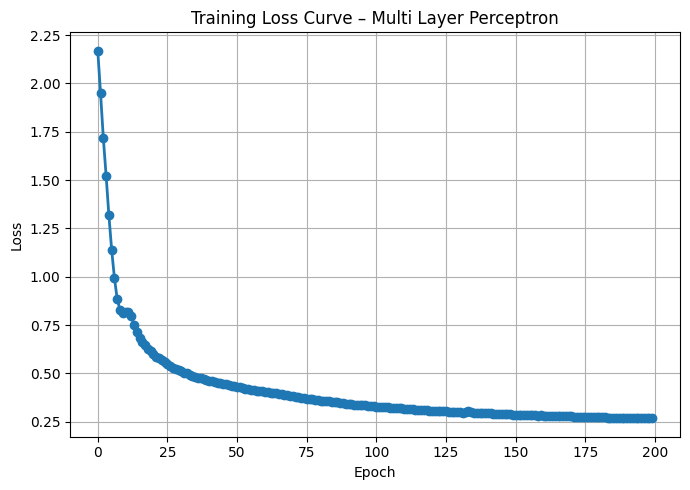

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_, marker='o', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve – Multi Layer Perceptron")
plt.grid(True)
plt.tight_layout()
plt.show()


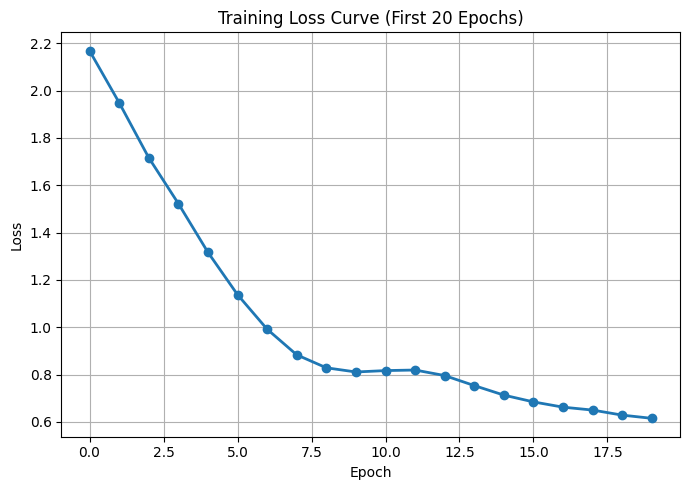

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_[:20], marker='o', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve (First 20 Epochs)")
plt.grid(True)
plt.tight_layout()
plt.show()


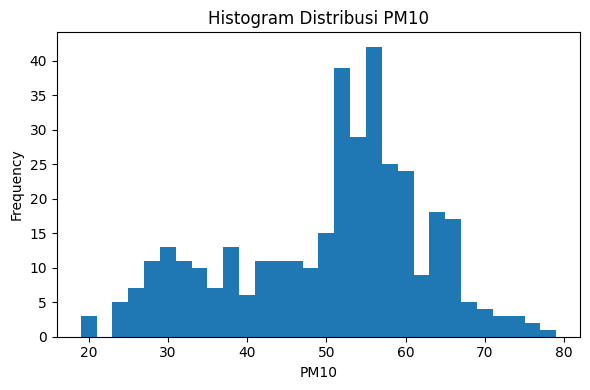

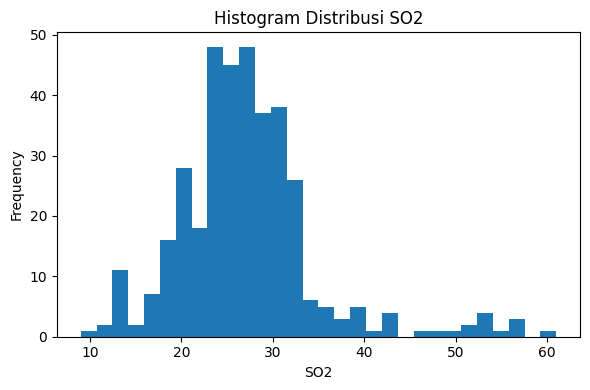

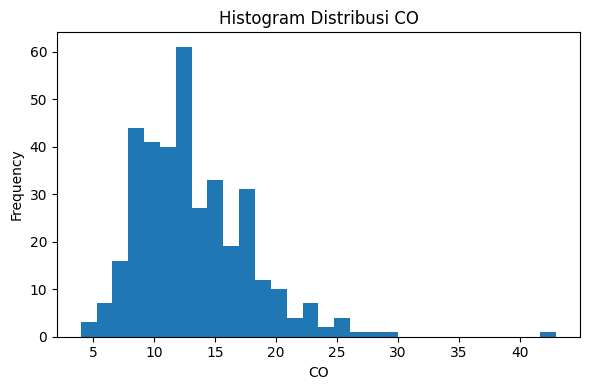

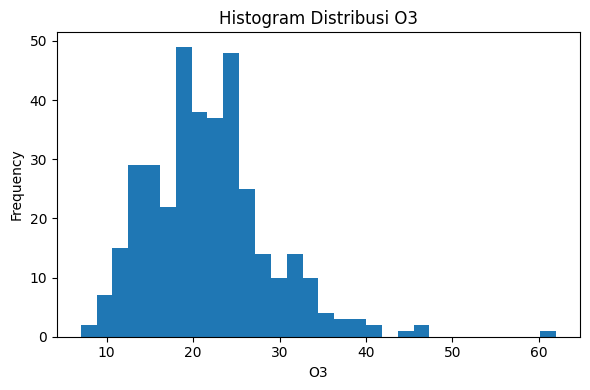

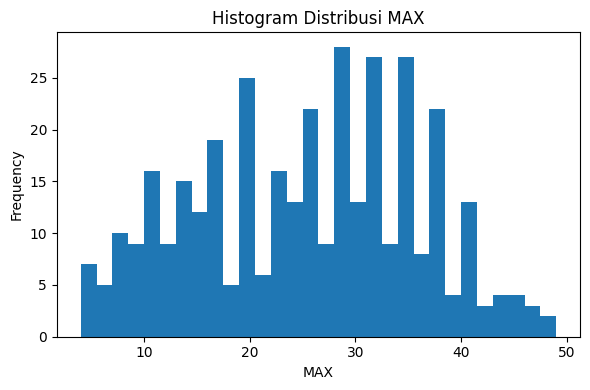

In [ ]:
X_np = X.values  # atau X.to_numpy()

feature_names = ['PM10', 'SO2', 'CO', 'O3', 'MAX']

for i in range(X_np.shape[1]):
    plt.figure(figsize=(6, 4))
    plt.hist(X_np[:, i], bins=30)
    plt.xlabel(feature_names[i])
    plt.ylabel("Frequency")
    plt.title(f"Histogram Distribusi {feature_names[i]}")
    plt.tight_layout()
    plt.show()

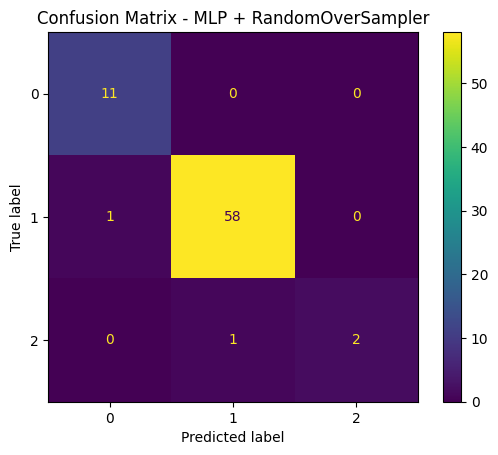

In [ ]:


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - MLP + RandomOverSampler")
plt.show()
